In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [40]:
x,y = make_moons(n_samples = 800, noise = 0.25)

In [41]:
df = {'x1':x[:,0],'x2':x[:,1], 'y':y}

In [42]:
data = pd.DataFrame(df)

In [43]:
data

,x1,x2,y
0,1.046176,-0.780074,1
1,-0.786446,1.011605,0
2,0.793992,-0.554553,1
3,-1.095210,0.425877,0
4,0.466296,0.943907,0
...,...,...,...
795,-0.102248,0.642818,1
796,-0.603412,0.574633,1
797,-0.249694,0.400734,1
798,1.835808,-0.369549,1


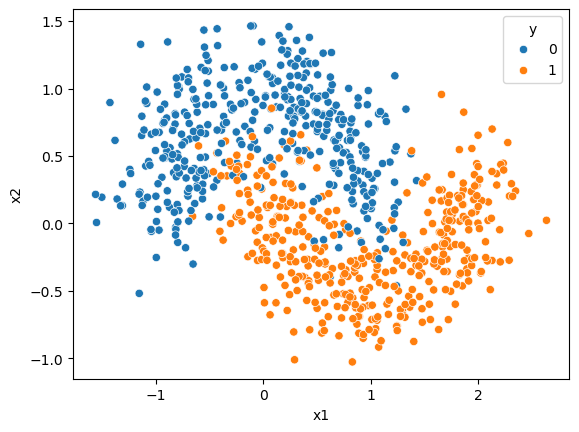

In [44]:
sns.scatterplot(x = 'x1', y = 'x2', data=data, hue='y' )
plt.show()

In [55]:
x = data.iloc[:, :-1]
y = data['y']

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.5, random_state = 39)

In [58]:
dtc = DecisionTreeClassifier(criterion = 'entropy')
dtc.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [84]:
dtc.score(x_train,y_train)*100,dtc.score(x_train, y_train)*100

(100.0, 100.0)

In [80]:
dtc.predict([[1.046176,-0.780074]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [75]:
s = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=39)
s.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [83]:
s.score(x_train,y_train)*100,s.score(x_train, y_train)*100

(93.25, 93.25)

In [79]:
s.predict([[1.046176,-0.780074]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1])

In [77]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,priors,None
,var_smoothing,1e-09


In [82]:
gnb.score(x_train,y_train)*100,gnb.score(x_train, y_train)*100

(88.25, 88.25)

In [81]:
gnb.predict([[1.046176,-0.780074]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [87]:
from sklearn.ensemble import VotingClassifier

In [89]:
li = [('dt',DecisionTreeClassifier()),('svm',SVC()),('gn',GaussianNB())]

In [100]:
vc = VotingClassifier(li, weights = [10,5,7])
vc.fit(x_train,y_train)

,estimators,"[('dt', ...), ('svm', ...), ...]"
,voting,'hard'
,weights,"[10, 5, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [101]:
vc.score(x_train,y_train)*100,gnb.score(x_train, y_train)*100

(94.0, 88.25)

In [93]:
vc.predict([[1.046176,-0.780074]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


array([1])

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [3]:
data = pd.read_csv('placement .csv')

In [4]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


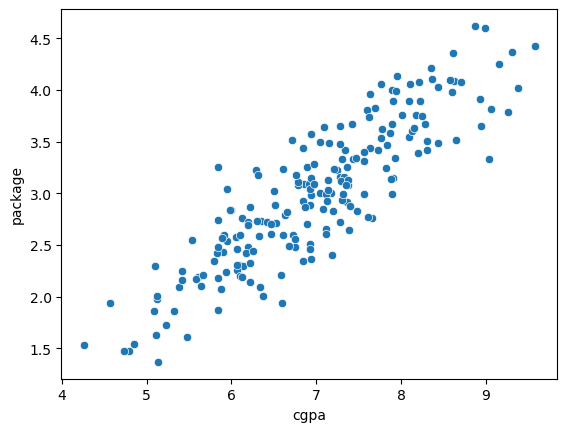

In [6]:
sns.scatterplot(x = 'cgpa', y = 'package', data = data)
plt.show()

In [7]:
x = data.iloc[:,:-1]
y = data['package']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.1, random_state = 39)

In [24]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
lr.score(x_train, y_train)*100,lr.score(x_test, y_test)*100

(77.95109292437353, 68.30086244711677)

In [32]:
lr.predict([[6.89]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.94694768])

In [26]:
s = SVR()
s.fit(x_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [29]:
s.score(x_train, y_train)*100,s.score(x_test, y_test)*100

(78.8103834335882, 61.16360721294709)

In [33]:
s.predict([[6.89]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


array([2.93857848])

In [30]:
dr = DecisionTreeRegressor()
dr.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [31]:
dr.score(x_train, y_train)*100,dr.score(x_test, y_test)*100

(95.65366961038218, 6.176740831064908)

In [34]:
dr.predict([[6.89]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([2.98])

In [35]:
from sklearn.ensemble import VotingRegressor

In [37]:
lr = [('lr',LinearRegression()),('s',SVR()), ('dtr',DecisionTreeRegressor())]

In [43]:
vr = VotingRegressor(lr,weights = [10,5,7])
vr.fit(x_train, y_train)

,estimators,"[('lr', ...), ('s', ...), ...]"
,weights,"[10, 5, ...]"
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,kernel,'rbf'
,degree,3


In [44]:
vr.score(x_train, y_train)*100,vr.score(x_test, y_test)*100

(87.72267118104952, 57.872860150682314)

In [45]:
vr.predict([[6.89]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([2.95556224])

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [47]:
x,y = make_moons(n_samples = 800, noise = 0.25)

In [48]:
df = {'x1':x[:,0],'x2':x[:,1], 'y':y}

In [49]:
data = pd.DataFrame(df)

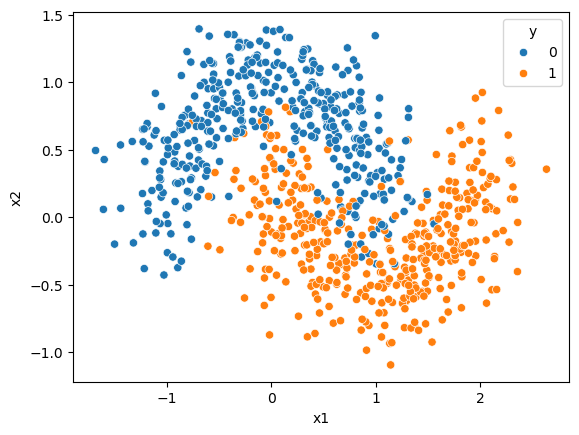

In [50]:
sns.scatterplot(x = 'x1', y = 'x2', data=data, hue='y' )
plt.show()

In [51]:
x = data.iloc[:, :-1]
y = data['y']

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.1, random_state = 39)

In [66]:
bc = BaggingClassifier(n_estimators =20)
bc.fit(x_train, y_train)

,estimator,None
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [71]:
bc.score(x_train,y_train)*100, bc.score(x_test,y_test)*100 # We can defined estimator like SVC, LinearRegression

(99.72222222222223, 91.25)

In [65]:
bc.predict([[0.466296,0.943907]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


array([0])

In [68]:
rf = RandomForestClassifier(n_estimators =20)
rf.fit(x_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100

(99.72222222222223, 92.5)

In [70]:
rf.predict([[0.466296,0.943907]])

/home/hp/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

In [75]:
r = rf.predict(x)

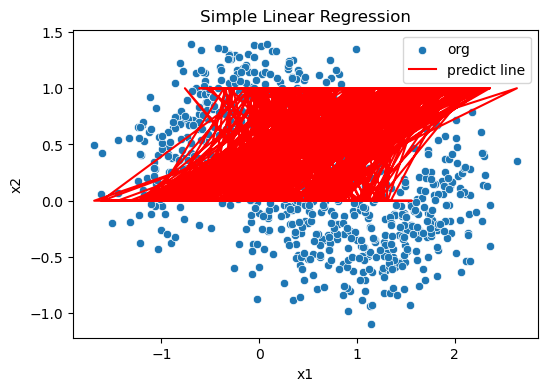

In [80]:
plt.figure(figsize = (6,4))
sns.scatterplot(x='x1', y = 'x2', data = data)
plt.plot(data['x1'],r, c = 'r')
plt.title('Simple Linear Regression')
plt.legend(['org', 'predict line'])
plt.show()

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [83]:
data = pd.read_csv('placement .csv')

In [84]:
x = data.iloc[:,:-1]
y = data['package']

In [85]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.1, random_state = 39)

In [95]:
bc = BaggingRegressor(estimator= SVR(),n_estimators =20)# We can defined estimator like SVC, LinearRegression
bc.fit(x_train, y_train)

,estimator,SVR()
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [96]:
bc.score(x_train,y_train)*100, bc.score(x_test,y_test)*100

(78.82530189223561, 60.216348436882505)

In [97]:
bc1 = BaggingRegressor(n_estimators =20)# We can defined estimator like SVC, LinearRegression
bc1.fit(x_train, y_train)

,estimator,None
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [98]:
bc1.score(x_train,y_train)*100, bc.score(x_test,y_test)*100

(92.25281544051983, 60.216348436882505)

In [99]:
rf = RandomForestRegressor(n_estimators =20)
rf.fit(x_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
rf.score(x_train,y_train)*100, rf.score(x_test,y_test)*100

(92.18069771265752, 35.9702049853146)